# Multi-Agent UPSC Essay Evaluation and Feedback System

In [27]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Annotated
from operator import add
from pydantic import BaseModel, Field
from langchain_deepseek import ChatDeepSeek
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from langchain_core.runnables import RunnableSequence
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
import os
load_dotenv()

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [28]:
# state of graph
class EssayState(TypedDict):
    topic: str
    content: str
    clarity_of_thought: str
    depth_of_analysis: str
    quality_of_language: str
    feedback: str
    scores: Annotated[List[int], add] # reducer used : add
    avg_score: float

In [29]:
# structured output format for parallel workflow nodes
class EvaluationSchema(BaseModel):
    reasoning: str = Field(description="Brief reasoning explaining why the essay received this score")
    score: int = Field(description="Score between 0 and 10", ge=0, le=10)

parser = PydanticOutputParser(pydantic_object=EvaluationSchema)

In [30]:
# clarity of thought
def evaluate_COT(state: EssayState):
    system_prompt = """
    You are an expert UPSC essay evaluator.

    Your task is to evaluate ONLY the clarity of thought in the essay written by a UPSC aspirant.

    Clarity of thought refers to:
    - How clearly the aspirant understands the essay topic.
    - Whether the ideas are logically connected.
    - Whether the argument progresses in a coherent manner.
    - Whether the reasoning is consistent and easy to follow.
    - Whether the essay avoids contradictions, unnecessary digressions, vague arguments, and logical gaps.
    - Whether the conclusion follows naturally from the ideas presented.

    Do NOT evaluate:
    - Grammar
    - Vocabulary
    - Spelling
    - Writing style
    - Handwriting
    - Factual accuracy
    - Number of examples
    - General UPSC essay quality

    Evaluate only the clarity and coherence of the aspirant's thinking.

    Give a score between 0 and 10:
    - 0–2: Very poor clarity of thought.
    - 3–4: Poor clarity.
    - 5–6: Moderate clarity.
    - 7–8: Good clarity.
    - 9–10: Excellent clarity.

    Return the evaluation using the required structured output format.
    """

    human_prompt = """
    Evaluate the following UPSC essay for clarity of thought.

    Essay Topic:
    {topic}

    Essay:
    {essay}

    {format_instructions}
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, parser)
    response = chain.invoke({"topic": state["topic"],
                             "essay": state["content"],
                             "format_instructions": parser.get_format_instructions()})

    return {"clarity_of_thought": response.reasoning, "scores": [response.score]}


In [31]:
# depth of analysis
def evaluate_DOA(state: EssayState):
    system_prompt = """
    You are an expert UPSC essay evaluator.

    Your task is to evaluate ONLY the depth of analysis demonstrated in the essay written by a UPSC aspirant.

    Depth of analysis refers to:
    - How deeply the aspirant explores the core dimensions and underlying aspects of the essay topic.
    - Whether the aspirant goes beyond superficial or obvious observations.
    - Whether the essay examines causes, consequences, implications, challenges, opportunities, and possible solutions where relevant.
    - Whether the aspirant explores the topic from multiple relevant perspectives and dimensions.
    - Whether the aspirant identifies underlying relationships, complexities, trade-offs, and interdependencies.
    - Whether the arguments are sufficiently developed and supported with meaningful reasoning.
    - Whether the essay demonstrates nuanced and mature thinking rather than merely listing points.
    - Whether the conclusion reflects the depth of analysis developed throughout the essay.

    Do NOT evaluate:
    - Grammar
    - Vocabulary
    - Spelling
    - Writing style
    - Handwriting
    - Factual accuracy
    - Number of examples
    - General UPSC essay quality
    - Clarity of thought, except where it directly affects the depth of analysis

    Evaluate only the depth and comprehensiveness of the aspirant's analysis of the topic.

    Give a score between 0 and 10:
    - 0–2: Very shallow analysis; mostly superficial observations with little exploration of the topic.
    - 3–4: Limited depth; some relevant analysis but largely focused on obvious or one-dimensional points.
    - 5–6: Moderate depth; explores several relevant aspects but lacks sufficient development, nuance, or deeper connections.
    - 7–8: Good depth; examines the topic from multiple relevant dimensions with well-developed and reasonably nuanced analysis.
    - 9–10: Excellent depth; demonstrates comprehensive, nuanced, multi-dimensional, and deeply reasoned analysis, including underlying causes, implications, complexities, and interconnections where relevant.

    Return the evaluation using the required structured output format.
    """

    human_prompt = """
    Evaluate the following UPSC essay for depth of analysis.

    Essay Topic:
    {topic}

    Essay:
    {essay}

    {format_instructions}
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, parser)
    response = chain.invoke({"topic": state["topic"],
                             "essay": state["content"],
                             "format_instructions": parser.get_format_instructions()})

    return {"depth_of_analysis": response.reasoning, "scores": [response.score]}


In [32]:
# quality of language
def evaluate_QOL(state: EssayState):
    system_prompt = """
    You are an expert UPSC essay evaluator.

    Your task is to evaluate ONLY the quality of language used in the essay written by a UPSC aspirant.

    Language quality refers to:
    - Grammatical correctness and sentence construction.
    - Clarity and precision of expression.
    - Appropriate and effective word choice.
    - Proper use of vocabulary without unnecessary complexity.
    - Ability to communicate ideas clearly and effectively through language.
    - Appropriate use of formal and academic language expected in a UPSC essay.
    - Sentence variety and readability.
    - Proper use of punctuation and paragraph-level expression.
    - Whether the language is natural, coherent, and easy to understand.

    Do NOT evaluate:
    - Depth of analysis
    - Clarity of thought or quality of reasoning
    - Factual accuracy
    - Number or quality of examples
    - General UPSC essay quality
    - Handwriting or presentation

    Evaluate only the quality of the language and expression used by the aspirant.

    Give a score between 0 and 10:

    - 0–2: Very poor language; frequent grammatical errors, unclear sentences, and significant difficulty in understanding the writing.
    - 3–4: Poor language; recurring grammatical and expression issues that frequently affect readability.
    - 5–6: Moderate language quality; generally understandable but contains noticeable grammatical, vocabulary, or expression issues.
    - 7–8: Good language; grammatically sound, clear, precise, and appropriate for a UPSC essay, with only minor issues.
    - 9–10: Excellent language; highly clear, precise, fluent, grammatically strong, and effective expression with sophisticated but natural vocabulary.

    Do not reward unnecessarily complicated vocabulary. Simple, precise, and effective language should receive a high score.

    Return the evaluation using the required structured output format.
    """

    human_prompt = """
    Evaluate the following UPSC essay for quality of language.

    Essay Topic:
    {topic}

    Essay:
    {essay}

    {format_instructions}
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, parser)
    response = chain.invoke({"topic": state["topic"],
                             "essay": state["content"],
                             "format_instructions": parser.get_format_instructions()})

    return {"quality_of_language": response.reasoning, "scores": [response.score]}


In [33]:
# Evaluator
def provide_feedback(state: EssayState):
    system_prompt = """
    You are an expert UPSC essay evaluator responsible for synthesizing feedback from multiple specialized evaluators.

    You will receive reasoning from three specialized evaluators who analyzed a UPSC essay on different dimensions:

    1. Clarity of Thought
    - Evaluates how clearly and coherently the aspirant's ideas are expressed.
    - Considers logical connections, progression of arguments, consistency, and logical gaps.

    2. Depth of Analysis
    - Evaluates how deeply the aspirant explores the topic.
    - Considers multiple relevant dimensions, underlying causes, consequences, implications, complexities, interconnections, and nuanced reasoning.

    3. Quality of Language
    - Evaluates the quality and effectiveness of the language used.
    - Considers grammar, sentence construction, vocabulary, precision, readability, and appropriateness of expression.

    Your task is to:

    - Analyze the reasoning provided by each evaluator.
    - Identify the key strengths and weaknesses mentioned across the three dimensions.
    - Identify recurring issues or patterns across the evaluations.
    - Identify any important disagreements or contrasting observations between the evaluators.
    - Synthesize the evaluator reasoning into concise, meaningful feedback for the UPSC aspirant.
    - Provide specific and actionable suggestions for improvement.

    Do NOT:
    - Calculate or provide any score.
    - Calculate an average score.
    - Infer or invent scores.
    - Independently evaluate the original essay.
    - Introduce observations that are not supported by the evaluator reasoning.

    Base your response ONLY on the reasoning provided by the three evaluators.
    """

    human_prompt = """
    Below are the reasoning provided by three specialized UPSC essay evaluators.

    Clarity of Thought - Reasoning:
    {clarity_reasoning}

    Depth of Analysis - Reasoning:
    {depth_reasoning}

    Quality of Language - Reasoning:
    {language_reasoning}

    Analyze and synthesize these evaluations.

    Focus on:
    - Key strengths across the three dimensions.
    - Most important weaknesses.
    - Recurring issues or patterns.
    - Specific and actionable improvements for the aspirant.

    Do not calculate, mention, or infer scores.
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke({"clarity_reasoning": state["clarity_of_thought"],
                             "depth_reasoning": state["depth_of_analysis"],
                             "language_reasoning": state["quality_of_language"]
                            })
    avg_score = sum(state["scores"])/len(state["scores"])

    return {"feedback": response, "avg_score": round(avg_score, 2)}


In [34]:
# graph
graph = StateGraph(EssayState)

# nodes
graph.add_node("evaluate_clarity", evaluate_COT)
graph.add_node("evaluate_depth", evaluate_DOA)
graph.add_node("evaluate_language", evaluate_QOL)
graph.add_node("feedback", provide_feedback)

# edges
graph.add_edge(START, "evaluate_clarity")
graph.add_edge(START, "evaluate_depth")
graph.add_edge(START, "evaluate_language")

graph.add_edge("evaluate_clarity", "feedback")
graph.add_edge("evaluate_depth", "feedback")
graph.add_edge("evaluate_language", "feedback")

graph.add_edge("feedback", END)

# compile
workflow = graph.compile()

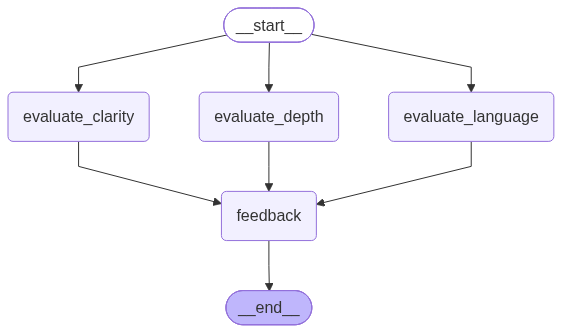

In [35]:
workflow

In [36]:
essay = """
Introduction

Every technological revolution has carried within it both a promise and a fear. The steam engine raised concerns about the displacement of manual labour; computers generated anxiety about the disappearance of clerical jobs; the internet transformed entire industries while rendering many traditional business models obsolete. Artificial Intelligence, however, appears different because it is not merely replacing physical effort—it is increasingly entering the domain of human cognition.

From writing and coding to medical diagnosis, financial analysis and customer service, AI can perform tasks that once required years of education and experience. This raises an uncomfortable question: Are we witnessing an AI takeover of human work, or merely another technological shift in the nature of employment?

The answer lies somewhere between the two. AI is unlikely to eliminate work itself, but it can radically transform what work means, who performs it, and what skills society values.

The Fear of an AI Takeover

The most immediate concern is job displacement. AI systems can automate repetitive, predictable and increasingly sophisticated cognitive tasks. A customer-service chatbot can handle thousands of queries simultaneously. Generative AI can draft reports, summarize documents, translate languages and produce software code. Automated systems can analyse financial data, detect manufacturing defects and assist in medical imaging.

The International Monetary Fund has estimated that AI could affect a substantial share of jobs globally, particularly in advanced economies where many occupations involve cognitive tasks. The concern, therefore, is not imaginary.

The danger is also unevenly distributed.

A highly skilled professional may use AI as a productivity tool and become more valuable, while a worker whose job consists largely of automatable tasks may find fewer opportunities. Thus, the central question may not be "Will AI replace humans?", but rather "Which humans will be replaced, and which humans will be empowered by AI?"

This distinction is crucial.

AI as a Shift Rather Than a Takeover

History suggests that technology rarely destroys employment in a simple one-for-one manner. It destroys certain tasks, changes occupations and creates new forms of economic activity.

The automobile reduced demand for horse-drawn carriages but created automobile manufacturing, repair, logistics and infrastructure industries. Computers eliminated many manual clerical processes but created software engineering, cybersecurity, IT services and digital businesses.

AI may follow a similar trajectory.

A doctor may not be replaced by AI, but a doctor using AI could replace one who does not. A lawyer may spend less time searching documents and more time advising clients. A programmer may write less boilerplate code and devote more time to architecture and problem-solving. A teacher may use AI to personalise learning while concentrating more on mentoring and emotional development.

Thus, the future may be characterised by human-AI collaboration rather than human-AI competition.

The most important economic transformation could therefore be the conversion of occupations rather than their complete disappearance.

The New Opportunities

Every disruption creates opportunities for those capable of adapting.

The AI economy will require specialists in machine learning, data engineering, robotics, cybersecurity and AI governance. But opportunities will not be limited to highly technical professions.

There will be growing demand for people who can combine domain expertise with AI literacy—AI-enabled doctors, lawyers, teachers, engineers, managers and administrators.

New professions may also emerge around AI auditing, model evaluation, safety, ethics, regulation, data governance and human-AI interaction.

For India, this transformation presents a particularly significant opportunity. With a large young population, a strong technology sector and a growing digital economy, India can become not merely a consumer of AI but a global centre for AI-enabled services.

However, this opportunity will materialise only if India invests in skills, infrastructure and inclusive access rather than assuming that technological progress automatically produces social progress.

The Hidden Risk: Inequality

The greatest danger of AI may not be mass unemployment alone. It may be mass inequality.

If the gains from AI accrue primarily to companies and individuals who own computing infrastructure, data, intellectual property and advanced skills, productivity may increase while wage growth stagnates for ordinary workers.

A highly productive economy can therefore coexist with a deeply unequal society.

There is also a geographical dimension. Urban, educated workers with access to technology may benefit disproportionately, while rural workers and people employed in informal sectors may struggle to participate in the AI economy.

India must therefore ensure that AI does not create a new form of digital divide—an intelligence divide between those who can leverage AI and those who cannot.

The Human Skills That Will Matter

Ironically, the rise of artificial intelligence may increase the importance of distinctly human capabilities.

Machines are becoming better at generating information. Humans will increasingly need to become better at judgement.

Critical thinking, creativity, empathy, leadership, ethical reasoning, communication and the ability to understand complex social contexts will become valuable.

Education, therefore, cannot remain focused primarily on memorisation. Students must learn how to ask meaningful questions, evaluate AI-generated information and make decisions under uncertainty.

The ideal worker of the future will not necessarily be the person who knows everything. It will be the person who knows how to learn, how to use intelligent tools and when not to trust them.

Preparing for the Aftermath

Technological transformation cannot be left entirely to market forces. Governments have a responsibility to manage the transition.

First, education systems must move towards lifelong learning. A degree obtained at the age of twenty cannot be expected to remain sufficient for an entire career in an economy where technology changes rapidly.

Second, governments and industries must create large-scale reskilling and upskilling programmes, particularly for workers in occupations exposed to automation.

Third, social-security systems must become more adaptable. Workers may experience periods of transition between occupations, making unemployment insurance, portable benefits and skill-development support increasingly important.

Fourth, India needs a robust framework for responsible AI. Issues relating to privacy, algorithmic discrimination, deepfakes, accountability and autonomous decision-making cannot be addressed after the technology has already transformed society.

Finally, the benefits of AI must be broadly distributed. Public investment in digital infrastructure, affordable computing, education and access to AI tools can prevent the technology from becoming the privilege of a small elite.

A Larger Philosophical Question

The AI debate ultimately forces humanity to confront a deeper question: What is the purpose of work?

For centuries, employment has been more than a means of earning income. It has provided identity, dignity, social interaction and a sense of contribution.

If AI eventually makes many forms of human labour unnecessary, society will have to rethink the relationship between work, income and dignity.

The goal should not simply be to maximise productivity. A society where machines produce enormous wealth but large sections of people feel economically useless cannot be considered truly prosperous.

Technology should free humans from meaningless work, not make humans feel meaningless.

Conclusion

AI is neither an inevitable apocalypse nor a magical solution to humanity's problems. It is a powerful general-purpose technology whose consequences will depend largely on how society chooses to deploy it.

The real choice is not between humans and machines, but between different models of a human-AI future.

If AI is governed poorly, it could deepen inequality, displace vulnerable workers and concentrate economic power. If managed wisely, it could increase productivity, improve public services, create new industries and free human beings from repetitive and hazardous work.

Therefore, the appropriate response is neither resistance to AI nor blind enthusiasm for it. It is prepared adaptation.

The defining skill of the AI age will not be the ability to compete with machines at what machines do best. It will be the ability to remain profoundly human while learning to work with them.

AI may indeed take away some jobs. But whether it takes away human dignity and opportunity is ultimately a political, economic and moral choice.

The future is therefore not simply an AI takeover. It is an AI shift—and the quality of that shift will depend on how wisely we prepare for it.
"""

In [37]:
# invoke
state = {
    "topic": "AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For",
    "content": essay
}

response = workflow.invoke(input=state)

In [38]:
response

{'topic': 'AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For',
 'content': '\nIntroduction\n\nEvery technological revolution has carried within it both a promise and a fear. The steam engine raised concerns about the displacement of manual labour; computers generated anxiety about the disappearance of clerical jobs; the internet transformed entire industries while rendering many traditional business models obsolete. Artificial Intelligence, however, appears different because it is not merely replacing physical effort—it is increasingly entering the domain of human cognition.\n\nFrom writing and coding to medical diagnosis, financial analysis and customer service, AI can perform tasks that once required years of education and experience. This raises an uncomfortable question: Are we witnessing an AI takeover of human work, or merely another technological shift in the nature of employment?\n\nThe answer lies somewhere between the two. AI 

In [39]:
response["avg_score"]

8.33

In [41]:
print(response["feedback"])

## Synthesis of Evaluator Feedback

### Overall Impression

The three evaluators present a largely consistent and strongly positive picture of the essay. The consistent themes across all dimensions are **structure, coherence, and polish**. The essay appears to have executed its core thesis with precision, both in thought and language. The only substantive area of concern arises from the Depth of Analysis evaluator, who identifies a ceiling on the essay's ambition—not a failure of quality, but a missed opportunity to reach the highest level of insight.

---

### Key Strengths Across the Three Dimensions

1. **Architectural Clarity (Clarity of Thought)**
   - The essay is described as having a balanced and sustained thesis: AI as a "shift" rather than a "takeover."
   - The evaluator highlights a perfect logical progression—each paragraph builds on the previous, from fear acknowledgment to historical reframing, opportunities, skills, and philosophical reflection.
   - There are no contra